<a href="https://colab.research.google.com/github/vorhersager/deep-learning-jax/blob/main/Tutorial_8_Investigating_Text_to_Image_Transformation_using_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 8: Investigating Text-to-Image Transformation using Diffusion

**Important:** Works best uaing High-RAM Accelerators available with the Colab Pro Plus subscription.


Instructor: John Sipple

### Overview

In this tutorial, we will explore the exact mathematical principles underlying state-of-the-art generative models like Google's Imagen and Midjourney. Unlike previous architectures that attempt to generate an image in a single shot, Diffusion Models operate on a fundamentally different paradigm: they learn to slowly sculpt a coherent image out of pure, random static.

By leveraging the JAX and Equinox ecosystem, we will build a complete text-to-image system comprising two primary components: a Transformer-based "Language Brain" (Text Encoder) to compress textual prompts into mathematical vectors, and an "Image Sculptor" (Conditioned U-Net) to subtract noise based on those text embeddings.

### Key Concepts Explored:

* **The Forward Process (Destruction via SDE):** Moving beyond discrete mathematical steps to model diffusion as a continuous Stochastic Differential Equation (SDE). You will implement a Variance Preserving (VP) SDE to simulate Langevin dynamics, systematically injecting standard Brownian noise to dissolve the Fashion-MNIST dataset into pure static.
* **The Reverse Process (Creation):** Training a deep Convolutional U-Net to reverse the thermodynamic destruction. By conditioning the network on the current timestep and the text embedding, the U-Net acts as a denoising engine, learning the underlying geometry of the data by predicting the exact noise that was added.
* **Classifier-Free Guidance (CFG):** Implementing the most impactful architectural "magic trick" used during inference. You will learn how to train the model on both conditional (prompted) and unconditional (unprompted) generation by randomly dropping text inputs. During inference, you will apply a guidance scale to extrapolate the difference between the two, forcing the model to produce exponentially crisper, highly text-aligned images.

### Real-World Application

Diffusion represents the current vanguard of AI research. Mastering these mechanics is essential for machine learning engineers looking to build custom generative design tools for rendering and architecture, develop automated marketing generation pipelines, or generate high-fidelity synthetic data for domains where real data is scarce or privacy-restricted.

In [ ]:
# --- Setup and Installation ---
!pip install -q equinox optax jax jaxlib matplotlib numpy torchvision

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import datasets

# Set precision
jax.config.update("jax_enable_x64", False)
print(f"JAX Devices: {jax.devices()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


JAX Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


#Part 1. The Forward Process (Continuous SDE)

Before we train neural networks, we must thoroughly understand the **Forward Process**—the mathematical mechanism that destroys our images.

In the original papers, diffusion was formulated as discrete mathematical steps. However, researchers later realized that the forward process is perfectly modeled by a continuous **Stochastic Differential Equation (SDE)**.

This connects deep learning to the physics of thermodynamics and Langevin dynamics!A common SDE used in image generation is the **Variance Preserving (VP) SDE**:


$$dx = -\frac{1}{2}\beta(t) x dt + \sqrt{\beta(t)} dw$$

* The **drift** term ($-\frac{1}{2}\beta(t) x dt$) slowly scales the original pixel values down toward zero.

The **diffusion** term ($\sqrt{\beta(t)} dw$) continually injects standard Brownian noise (static) into the image.

Let's generate a simple image with two Gaussian blobs and simulate this SDE over time to watch the image dissolve into pure noise.

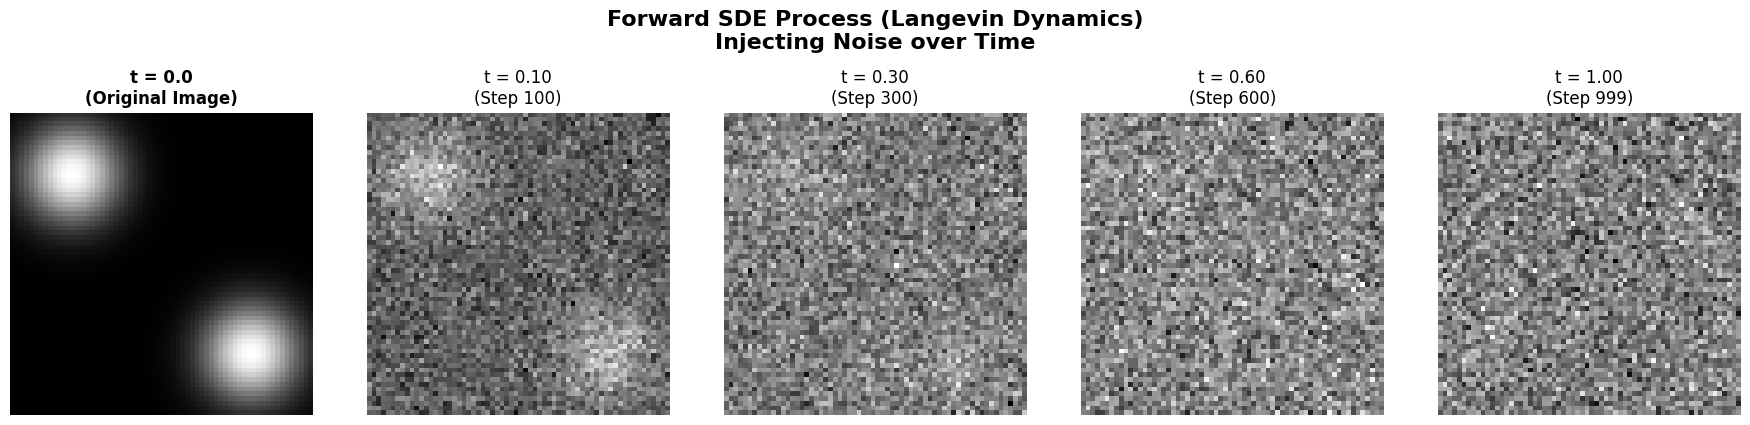

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# --- 1. Create the Initial Image (x_0) ---
size = 64
x, y = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))

# Two Gaussian blobs in opposite corners
blob1 = np.exp(-10 * ((x + 0.6)**2 + (y + 0.6)**2)) # Bottom-Left
blob2 = np.exp(-10 * ((x - 0.6)**2 + (y - 0.6)**2)) # Top-Right

x_0 = blob1 + blob2
x_0 = x_0 / np.max(x_0) # Normalize to [0, 1]

# --- 2. Simulate Forward SDE (Variance Preserving) ---
num_steps = 1000
dt = 1.0 / num_steps

# Linear beta schedule (Noise scales up over time)
beta_min = 0.1
beta_max = 20.0

def beta_t(t):
    return beta_min + t * (beta_max - beta_min)

# Plotting setup
timesteps_to_plot = [0, 100, 300, 600, 999]
fig, axes = plt.subplots(1, len(timesteps_to_plot), figsize=(18, 4))

x_t = x_0.copy()
plot_idx = 0

# Plot t=0
axes[plot_idx].imshow(x_t, cmap='gray')
axes[plot_idx].set_title("t = 0.0\n(Original Image)", fontsize=12, weight='bold')
axes[plot_idx].axis('off')
plot_idx += 1

# Euler-Maruyama Integration Loop
for step in range(1, num_steps):
    t = step * dt
    beta = beta_t(t)

    # 1. Generate Brownian noise increment (dw)
    dw = np.random.normal(size=x_t.shape) * np.sqrt(dt)

    # 2. Calculate the SDE step (dx)
    dx = -0.5 * beta * x_t * dt + np.sqrt(beta) * dw

    # 3. Apply the step
    x_t = x_t + dx

    # Plot specific milestones
    if step in timesteps_to_plot:
        axes[plot_idx].imshow(x_t, cmap='gray')
        axes[plot_idx].set_title(f"t = {t:.2f}\n(Step {step})", fontsize=12)
        axes[plot_idx].axis('off')
        plot_idx += 1

plt.suptitle("Forward SDE Process (Langevin Dynamics)\nInjecting Noise over Time", fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

#Part 2: Downloading the Captioned "Real-World" Dataset
To make this feasible for Colab, we will download the Fashion-MNIST dataset and synthesize a text caption for each image based on its label.

In [ ]:
# --- 1. Download Dataset ---
print("Downloading Fashion MNIST...")
fmnist = datasets.FashionMNIST('./data', train=True, download=True)

# We will take a tiny subset (1000 images) for rapid classroom training
X_data = fmnist.data.numpy()[:1000]
Y_labels = fmnist.targets.numpy()[:1000]

# Normalize to [-1, 1] for diffusion
X_data = (X_data.astype(np.float32) / 127.5) - 1.0
X_data = X_data[:, None, :, :] # (Batch, Channels, H, W) -> (1000, 1, 28, 28)

# --- 2. Synthesize Captions ---
label_map = {
    0: "a T-shirt", 1: "a pair of trousers", 2: "a pullover sweater",
    3: "a dress", 4: "a coat", 5: "a sandal",
    6: "a shirt", 7: "a sneaker", 8: "a bag", 9: "an ankle boot"
}

captions = [f"A black and white image of {label_map[y]}" for y in Y_labels]

# Create a simple vocabulary and tokenizer
vocab = list(set(" ".join(captions).split()))
vocab.append("<PAD>")
stoi = {word: i for i, word in enumerate(vocab)}

def tokenize(caption, max_len=8):
    tokens = [stoi[w] for w in caption.split()]
    # Pad to max_len
    tokens = tokens + [stoi["<PAD>"]] * (max_len - len(tokens))
    return jnp.array(tokens[:max_len])

# Tokenize all captions
C_data = jnp.stack([tokenize(c) for c in captions])

print(f"Images shape: {X_data.shape}")
print(f"Captions shape: {C_data.shape}")
print(f"Example Caption: '{captions[0]}'")
print(f"vocabulary: {vocab}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 264kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.5MB/s]


Images shape: (1000, 1, 28, 28)
Captions shape: (1000, 8)
Example Caption: 'A black and white image of an ankle boot'
vocabulary: ['trousers', 'A', 'boot', 'image', 'black', 'bag', 'sandal', 'white', 'a', 'T-shirt', 'and', 'coat', 'of', 'pair', 'shirt', 'sneaker', 'pullover', 'ankle', 'sweater', 'an', 'dress', '<PAD>']


Rendering sample pairs...


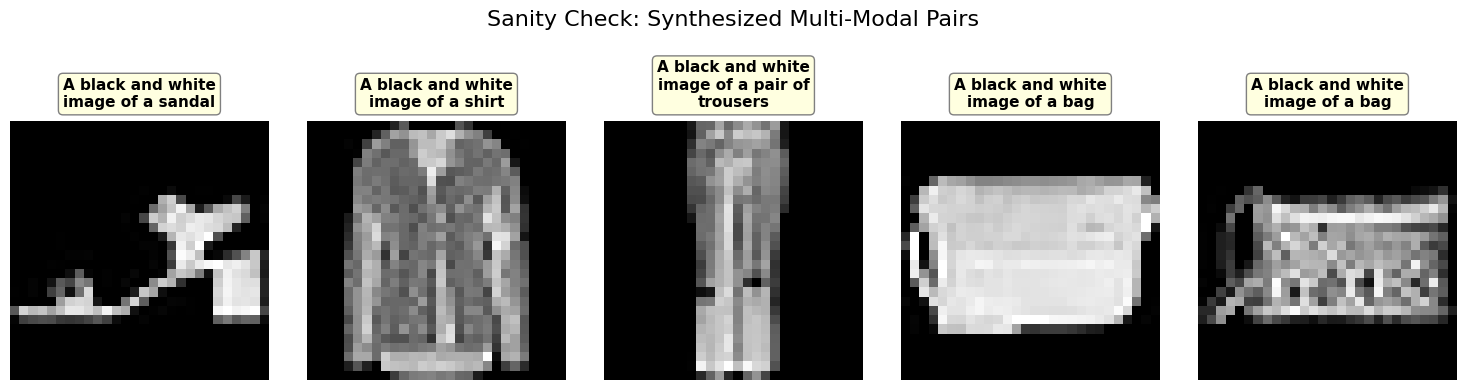

In [ ]:
import textwrap

# --- 3. Visualize Image-Caption Pairs ---
def show_captioned_examples(images, text_captions, num_examples=5):
    fig, axes = plt.subplots(1, num_examples, figsize=(15, 3.5))

    # Pick random indices to inspect
    np.random.seed(42) # Set seed for reproducibility in the classroom
    indices = np.random.choice(len(images), num_examples, replace=False)

    for i, idx in enumerate(indices):
        # The images are currently in [-1, 1] for diffusion.
        # We shift them back to [0, 1] so Matplotlib can render them correctly.
        display_img = (images[idx, 0] + 1.0) / 2.0

        axes[i].imshow(display_img, cmap='gray')

        # Wrap the caption text so it fits neatly above the image
        wrapped_caption = "\n".join(textwrap.wrap(text_captions[idx], width=22))

        # We use a slight background color on the title to make it look like a "caption box"
        axes[i].set_title(wrapped_caption, fontsize=11, weight='bold', pad=10,
                          bbox=dict(facecolor='lightyellow', edgecolor='gray', boxstyle='round,pad=0.3'))
        axes[i].axis('off')

    plt.suptitle("Sanity Check: Synthesized Multi-Modal Pairs", fontsize=16, y=1.1)
    plt.tight_layout()
    plt.show()

# Render 5 random examples
print("Rendering sample pairs...")
show_captioned_examples(X_data, captions, num_examples=5)

# Part 3: The Forward Diffusion Process (Adding Noise)

Diffusion models rely on a fixed forward process that gradually adds Gaussian noise to an image over $T$ timesteps, governed by a variance schedule $\beta_1, \dots, \beta_T$.

Thanks to the reparameterization trick, we can jump to any arbitrary timestep $t$ in a single calculation:

$$q(x_t | x_0) = \mathscr{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) \mathbf{I})$$

Where $\bar{\alpha}_t = \prod_{i=1}^t (1 - \beta_i)$.

Let's visualize this destruction of data.

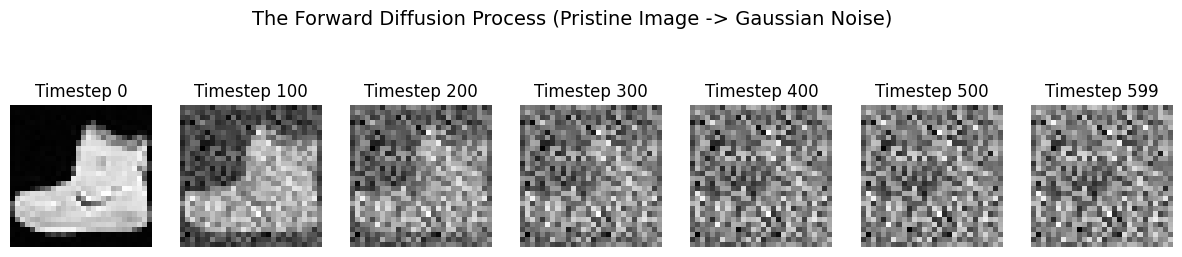

In [ ]:
# --- Diffusion Hyperparameters ---
TIMESTEPS = 600
beta = jnp.linspace(0.0001, 0.02, TIMESTEPS)
alpha = 1.0 - beta
alpha_bar = jnp.cumprod(alpha)

def q_sample(x_0, t, noise):
    """Forward diffusion: Adds noise to x_0 up to timestep t."""
    sqrt_alpha_bar_t = jnp.sqrt(alpha_bar[t])
    sqrt_one_minus_alpha_bar_t = jnp.sqrt(1.0 - alpha_bar[t])

    # Match shapes for broadcasting
    sqrt_alpha_bar_t = sqrt_alpha_bar_t[:, None, None, None]
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t[:, None, None, None]

    return sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise

# --- Render the Forward Process ---
sample_img = jnp.array(X_data[0:1])
rng = jax.random.PRNGKey(42)
noise = jax.random.normal(rng, sample_img.shape)

stages = list(range(0, TIMESTEPS, int(TIMESTEPS/6))) + [TIMESTEPS -1]
fig, axes = plt.subplots(1, len(stages), figsize=(15, 3))

for i, t in enumerate(stages):
    t_tensor = jnp.array([t])
    x_t = q_sample(sample_img, t_tensor, noise)
    axes[i].imshow(x_t[0, 0], cmap='gray')
    axes[i].set_title(f"Timestep {t}")
    axes[i].axis('off')

plt.suptitle("The Forward Diffusion Process (Pristine Image -> Gaussian Noise)", y=1.05, fontsize=14)
plt.show()

#Part 3: Investigating the Vector Field (Score Function)

We've stated that the **Score Function** ($\nabla_x \log p(x)$) is a continuous vector field that points toward the highest probability density of our data. But what does that actually look like?

Let's strip away the neural network for a moment. Imagine a toy dataset that only consists of two pure clusters of data (for example, "Shirts" in the top-right and "Shoes" in the bottom-left). Mathematically, we can model this as a mixture of two Gaussian distributions.

Because we know the exact mathematical equations for these Gaussians, we don't need a U-Net to guess the score. We can calculate the exact calculus derivative of the probability distribution and plot it!

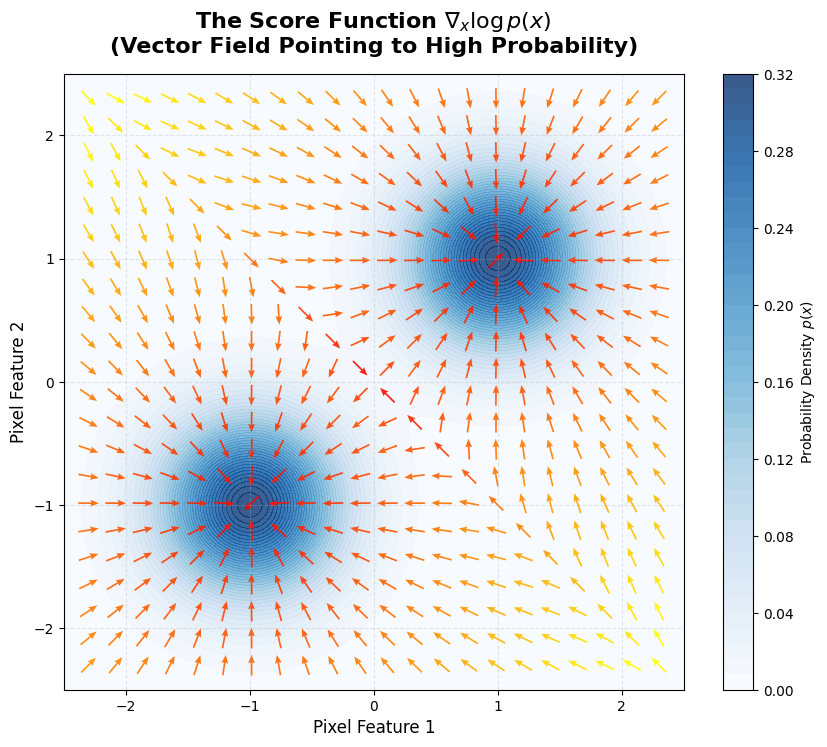

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define our "Dataset" (Two Gaussian Clusters) ---
# Bottom-Left Cluster (e.g., "Shoes")
mu1 = np.array([-1.0, -1.0])
# Top-Right Cluster (e.g., "Shirts")
mu2 = np.array([1.0, 1.0])
sigma = 0.5  # Spread of the clusters

def gaussian_pdf(x, y, mu, sigma):
    """Calculates the probability density of a Gaussian."""
    return (1.0 / (2 * np.pi * sigma**2)) * np.exp(-((x - mu[0])**2 + (y - mu[1])**2) / (2 * sigma**2))

def gaussian_grad(x, y, mu, sigma, pdf_val):
    """Calculates the exact gradient (derivative) of a Gaussian."""
    grad_x = -((x - mu[0]) / sigma**2) * pdf_val
    grad_y = -((y - mu[1]) / sigma**2) * pdf_val
    return grad_x, grad_y

# --- 2. Calculate the PDF on a fine grid (for the background colors) ---
x_fine = np.linspace(-2.5, 2.5, 300)
y_fine = np.linspace(-2.5, 2.5, 300)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)

pdf1_fine = gaussian_pdf(X_fine, Y_fine, mu1, sigma)
pdf2_fine = gaussian_pdf(X_fine, Y_fine, mu2, sigma)
p_fine = 0.5 * pdf1_fine + 0.5 * pdf2_fine

# --- 3. Calculate the Score on a coarse grid (for the arrows) ---
x_coarse = np.linspace(-2.3, 2.3, 22)
y_coarse = np.linspace(-2.3, 2.3, 22)
X_coarse, Y_coarse = np.meshgrid(x_coarse, y_coarse)

pdf1_coarse = gaussian_pdf(X_coarse, Y_coarse, mu1, sigma)
pdf2_coarse = gaussian_pdf(X_coarse, Y_coarse, mu2, sigma)
p_coarse = 0.5 * pdf1_coarse + 0.5 * pdf2_coarse

# Combine Gradients
grad1_x, grad1_y = gaussian_grad(X_coarse, Y_coarse, mu1, sigma, pdf1_coarse)
grad2_x, grad2_y = gaussian_grad(X_coarse, Y_coarse, mu2, sigma, pdf2_coarse)
grad_p_x = 0.5 * grad1_x + 0.5 * grad2_x
grad_p_y = 0.5 * grad1_y + 0.5 * grad2_y

# ** THE SCORE FUNCTION ** = Gradient of the Probability / Probability
score_x = grad_p_x / p_coarse
score_y = grad_p_y / p_coarse

# Normalize the arrows so they are all the same length for visualization,
# but we will use the magnitude to color them!
magnitude = np.sqrt(score_x**2 + score_y**2)
magnitude[magnitude == 0] = 1.0
score_x_norm = score_x / magnitude
score_y_norm = score_y / magnitude

# --- 4. Render the Plot ---
plt.figure(figsize=(10, 8))

# Draw the blue topographic density map
contour = plt.contourf(X_fine, Y_fine, p_fine, levels=50, cmap='Blues', alpha=0.8)
plt.colorbar(contour, label='Probability Density $p(x)$')

# Draw the vector field arrows
# Yellow/Red indicates higher pull magnitude
plt.quiver(X_coarse, Y_coarse, score_x_norm, score_y_norm, magnitude,
           cmap='autumn', pivot='mid', scale=30, headwidth=4, alpha=0.9)

plt.title("The Score Function $\\nabla_x \\log p(x)$ \n(Vector Field Pointing to High Probability)", fontsize=16, weight='bold', pad=15)
plt.xlabel("Pixel Feature 1", fontsize=12)
plt.ylabel("Pixel Feature 2", fontsize=12)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##The Reverse Process (Untrained Unconditional Generation)

We have seen the Forward Process destroy data. The Reverse Process aims to undo this by starting with pure Gaussian noise ($x_T$) and iteratively subtracting the noise predicted by a neural network until we reach a clean image ($x_0$).

Before we build our complex Text-Conditioned architecture, let's build a simple Unconditional **U-Net**. This network only looks at the noisy image $x_t$ and the timestep $t$.

We will initialize this U-Net with random weights and immediately run the reverse generation loop. What happens when an untrained model tries to denoise an image?

Whenever we ask the U-Net to predict the noise $\epsilon$, we are mathematically calculating the score.

Let's break down exactly how this works and where it is happening in this colab.

###1. What is the Score Function?

In statistics, the "score" is the gradient of the log probability density of data:

$$\nabla_{x} \log p(x)$$

Visually, imagine a topographic map where the "peaks" are real, crisp Fashion-MNIST images, and the "valleys" are pure static. The score function is a vector field that always points uphill. If you drop a noisy image on this map, the score tells you exactly which direction to step to reach a real image.

###2. The Mathematical Equivalency

In 2020, researchers proved a beautiful equivalence between predicting noise and predicting the score.

If you know the noise $\epsilon$ that was added to an image to get $x_t$, you can find the direction of the clean image. Therefore, the score function $s_\theta$ is directly proportional to the U-Net's noise prediction $\epsilon_\theta$:

$$s_\theta(x_t, t) = -\frac{\epsilon_\theta(x_t, t)}{\sqrt{1 - \bar{\alpha}_t}}$$

Because they are proportional, we don't need to explicitly compute complex gradients during training. We just train the network to guess the noise!


###3. Where is it applied in the code?
You are applying the score function in exactly two places:

####a. During Training (Score Matching)
In your loss_fn, you have this line: `predicted_noise = jax.vmap(model)(x_t, t, tokens)`


By forcing the U-Net to accurately predict the injected Gaussian noise using Mean Squared Error, you are technically performing Denoising Score Matching. You are training the vector field to point toward the clean data distribution.

####b. During Inference (Langevin Dynamics)
In your reverse_step function, you have this block:


```
# 1. Evaluate the Score Function
pred_noise = model(x_t, t, tokens)

# 2. Step in the direction of the Score
mean = (1 / jnp.sqrt(a_t)) * (x_t - (b_t / jnp.sqrt(1 - a_bar_t)) * pred_noise)
```

When we subtract a fraction of pred_noise from $x_t$, we are doing Gradient Ascent on the probability distribution. We are following the vector field "uphill" to remove the noise and reveal the image.

Instantiated Deep Unconditional U-Net
Training Unconditional U-Net...
Epoch 10/50 | Train Loss: 0.2976 | Test Loss: 0.3766
Epoch 20/50 | Train Loss: 0.2088 | Test Loss: 0.1891
Epoch 30/50 | Train Loss: 0.2103 | Test Loss: 0.2199
Epoch 40/50 | Train Loss: 0.1708 | Test Loss: 0.2215
Epoch 50/50 | Train Loss: 0.1787 | Test Loss: 0.1847


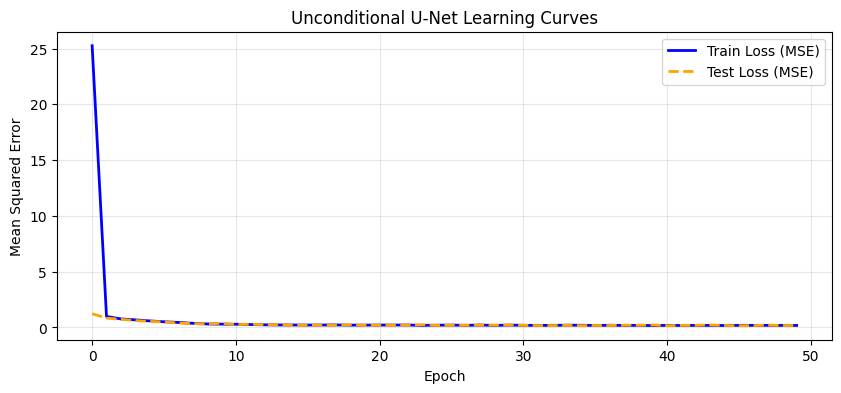


Running reverse diffusion with TRAINED model...


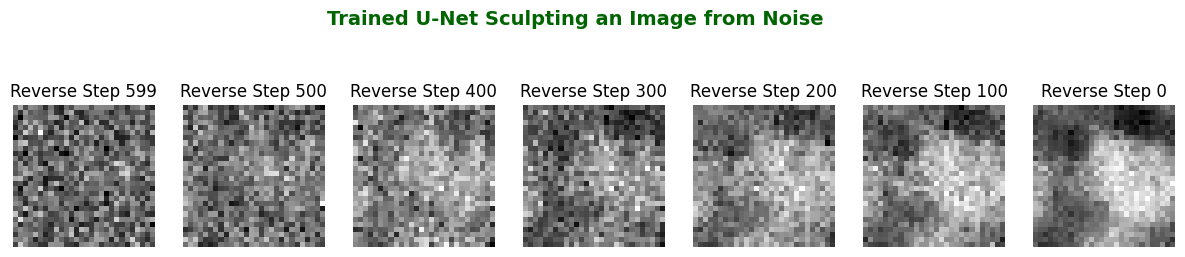

In [ ]:
from torch.serialization import T
# --- 1. Parameterized Unconditional U-Net ---
class DeepUnconditionalUNet(eqx.Module):
    conv_in: eqx.nn.Conv2d
    down_blocks: list
    time_proj: eqx.nn.Linear
    up_blocks: list
    conv_out: eqx.nn.Conv2d

    def __init__(self, in_channels, base_channels, num_layers, key):
        keys = jax.random.split(key, 3 + 2 * num_layers)

        # 1. Input processing
        self.conv_in = eqx.nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1, key=keys[0])

        # 2. Dynamic Down blocks (Double the channels, Halve the spatial)
        self.down_blocks = []
        curr_channels = base_channels
        for i in range(num_layers):
            self.down_blocks.append(
                eqx.nn.Conv2d(curr_channels, curr_channels * 2, kernel_size=3, stride=2, padding=1, key=keys[1 + i])
            )
            curr_channels *= 2

        # 3. Bottleneck (Inject Time)
        self.time_proj = eqx.nn.Linear(1, curr_channels, key=keys[1 + num_layers])

        # 4. Dynamic Up blocks (Halve the channels, Double the spatial)
        self.up_blocks = []
        for i in range(num_layers):
            self.up_blocks.append(
                eqx.nn.ConvTranspose2d(
                    curr_channels, curr_channels // 2,
                    kernel_size=3, stride=2, padding=1, output_padding=1,
                    key=keys[2 + num_layers + i]
                )
            )
            curr_channels //= 2

        # 5. Output processing
        self.conv_out = eqx.nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1, key=keys[-1])

    def __call__(self, x_t, t):
        # Initial convolution
        h = jax.nn.relu(self.conv_in(x_t))

        # We use a list as a Stack to keep track of skip connections!
        skips = [h]

        # Downward path
        for down in self.down_blocks:
            h = jax.nn.relu(down(h))
            skips.append(h)

        # Pop the very last item off the stack, as this is the bottleneck itself.
        # (We don't want to skip-connect the bottleneck to the bottleneck)
        bottleneck = skips.pop()

        # Inject Time into the bottleneck
        t_1d = jnp.atleast_1d(t).astype(jnp.float32)
        t_emb = self.time_proj(t_1d)
        h = bottleneck + t_emb[:, None, None]

        # Upward path
        for up in self.up_blocks:
            h = jax.nn.relu(up(h))
            # Grab the corresponding skip connection from the stack and add it
            h = h + skips.pop()

        return self.conv_out(h)

# --- 2. Train / Test Split & Training Setup ---
# Split our 1000 images: 900 for training, 100 for testing
X_train_uncond = X_data[:900]
X_test_uncond = X_data[900:]

# Instantiate our new dynamic U-Net!
# For Fashion MNIST (28x28), we use 2 layers (28 -> 14 -> 7)
uncond_model = DeepUnconditionalUNet(
    in_channels=1,
    base_channels=32,
    num_layers=2,
    key=jax.random.PRNGKey(555)
)

print("Instantiated Deep Unconditional U-Net")

uncond_optim = optax.adam(2e-3)
uncond_opt_state = uncond_optim.init(eqx.filter(uncond_model, eqx.is_array))

def uncond_loss_fn(model, x_0, t, noise):
    x_t = q_sample(x_0, t, noise)

    predicted_noise = jax.vmap(model)(x_t, t)
    return jnp.mean(jnp.square(noise - predicted_noise))

@eqx.filter_jit
def uncond_train_step(model, opt_state, x_0, t, noise):
    loss, grads = eqx.filter_value_and_grad(uncond_loss_fn)(model, x_0, t, noise)
    updates, opt_state = uncond_optim.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

@eqx.filter_jit
def uncond_eval_step(model, x_0, t, noise):
    return uncond_loss_fn(model, x_0, t, noise)

# --- 3. Training Loop with Learning Curves ---
print("Training Unconditional U-Net...")
UNCOND_EPOCHS = 50
BATCH_SIZE = 64
rng = jax.random.PRNGKey(888)

train_losses = []
test_losses = []

for epoch in range(UNCOND_EPOCHS):
    epoch_loss = 0.0
    n_batches = len(X_train_uncond) // BATCH_SIZE
    rng, shuffle_key = jax.random.split(rng)
    indices = jax.random.permutation(shuffle_key, len(X_train_uncond))

    # -- Training Phase --
    for i in range(n_batches):
        bx = X_train_uncond[indices[i*BATCH_SIZE:(i+1)*BATCH_SIZE]]
        rng, t_key, n_key = jax.random.split(rng, 3)
        bt = jax.random.randint(t_key, (bx.shape[0],), 0, TIMESTEPS)
        bnoise = jax.random.normal(n_key, bx.shape)

        uncond_model, uncond_opt_state, loss = uncond_train_step(uncond_model, uncond_opt_state, bx, bt, bnoise)
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # -- Evaluation Phase --
    rng, t_test_key, n_test_key = jax.random.split(rng, 3)
    test_batch_size = len(X_test_uncond)
    test_t = jax.random.randint(t_test_key, (test_batch_size,), 0, TIMESTEPS)
    test_noise = jax.random.normal(n_test_key, X_test_uncond.shape)

    test_loss = uncond_eval_step(uncond_model, X_test_uncond, test_t, test_noise).item()
    test_losses.append(test_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{UNCOND_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Plot Learning Curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss (MSE)", color="blue", linewidth=2)
plt.plot(test_losses, label="Test Loss (MSE)", color="orange", linewidth=2, linestyle="--")
plt.title("Unconditional U-Net Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. Unconditional Reverse Step & Generation ---
@eqx.filter_jit
def unconditional_reverse_step(model, x_t, t, t_index):
    # 1. Evaluate the Score Function
    pred_noise = model(x_t, t)
    b_t = beta[t]
    a_t = alpha[t]
    a_bar_t = alpha_bar[t]

    # 2. Step in the direction of the Score
    mean = (1 / jnp.sqrt(a_t)) * (x_t - (b_t / jnp.sqrt(1 - a_bar_t)) * pred_noise)

    def add_noise():
        rng = jax.random.PRNGKey(t_index)
        z = jax.random.normal(rng, x_t.shape)
        return mean + jnp.sqrt(b_t) * z

    return jax.lax.cond(t > 0, add_noise, lambda: mean)

def generate_unconditional(model):
    print("\nRunning reverse diffusion with TRAINED model...")
    rng = jax.random.PRNGKey(777)
    x = jax.random.normal(rng, (1, 28, 28))

    history = []
    num_steps = int(TIMESTEPS/6)
    for t_idx in reversed(range(TIMESTEPS)):
        x = unconditional_reverse_step(model, x, t_idx, t_idx)
        if t_idx % num_steps == 0 or t_idx == TIMESTEPS - 1:
            history.append((t_idx, np.array(x)))

    fig, axes = plt.subplots(1, len(history), figsize=(15, 3))
    for i, (t, img) in enumerate(history):
        # Shift back to [0, 1] for visualization
        display_img = (img[0] + 1.0) / 2.0
        axes[i].imshow(display_img, cmap='gray')
        axes[i].set_title(f"Reverse Step {t}")
        axes[i].axis('off')

    plt.suptitle("Trained U-Net Sculpting an Image from Noise", y=1.05, fontsize=14, color='darkgreen', weight='bold')
    plt.show()

generate_unconditional(uncond_model)

#Part 5: The Conditioning (Text Encoder) & Denoising U-Net

Above, our Unconditional U-Net sculpted a clean image out of pure static. But there is a glaring problem: **we have absolutely no control over what it makes**. It might generate a shoe, a bag, or a shirt entirely at random.

To turn this into a true Text-to-Image model, we need to give the U-Net a "steering wheel." We need to condition its noise predictions on a specific user request.

##The Language Barrier
Our U-Net is a Convolutional Neural Network; it only understands grids of numbers representing visual features. It does not speak English. If we hand the U-Net the text string "*a dark pair of shoes*", it will crash.

To bridge this gap, we must introduce an entirely different kind of neural network to act as a mathematical translator: the Text Encoder.

##What is a Text Encoder?

A Text Encoder (usually a Transformer architecture, like the one powering large language models) reads human text and compresses its semantic meaning into a dense array of numbers called a Context Vector ($C$).The process works in four steps:

1. **Tokenization**: The text is chopped into smaller pieces (tokens) and mapped to a numerical vocabulary ID.

2. **Embedding**: Each token ID is turned into a continuous vector.

3. **Self-Attention**: The Transformer analyzes how the words relate to each other contextually (e.g., understanding that "dark" modifies "shoes", not "pair").

4. **Projection**: It squashes this understanding down into a single, fixed-size 1D vector (e.g., an array of 64 numbers).

##The Bottleneck Injection

Once the Text Encoder produces this Context Vector $C$, we inject it directly into the Bottleneck of the U-Net.

Now, at every single step of the reverse diffusion process, the U-Net looks at the noisy image, looks at the timestep $t$, and looks at the context vector $C$. Instead of asking, "*What is the most likely noise to subtract?*" the U-Net asks, "*What is the most likely noise to subtract given that the final image must look like a dark pair of shoes?*"

In [ ]:
# --- 1. Text Encoder (Tiny Transformer) ---
class TextEncoder(eqx.Module):
    embedding: eqx.nn.Embedding
    transformer: eqx.nn.MultiheadAttention
    proj: eqx.nn.Linear

    def __init__(self, vocab_size, d_model, key):
        k1, k2, k3 = jax.random.split(key, 3)
        self.embedding = eqx.nn.Embedding(vocab_size, d_model, key=k1)
        self.transformer = eqx.nn.MultiheadAttention(num_heads=2, query_size=d_model, key=k2)
        self.proj = eqx.nn.Linear(d_model, 64, key=k3)

    def __call__(self, tokens):
        # Embed tokens (Seq_Len, D_Model)
        x = jax.vmap(self.embedding)(tokens)
        # Self-Attention
        x = self.transformer(query=x, key_=x, value=x)
        # Average over sequence length to get a single context vector
        x = jnp.mean(x, axis=0)
        return self.proj(x)

# --- 2. Score-Based U-Net Denoiser ---
class ConditionalUNet(eqx.Module):
    conv_in: eqx.nn.Conv2d
    down: eqx.nn.Conv2d
    up: eqx.nn.ConvTranspose2d
    conv_out: eqx.nn.Conv2d

    # Conditioning layers
    time_proj: eqx.nn.Linear
    context_proj: eqx.nn.Linear

    def __init__(self, key):
        keys = jax.random.split(key, 6)
        self.conv_in = eqx.nn.Conv2d(1, 16, kernel_size=3, padding=1, key=keys[0])
        self.down = eqx.nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, key=keys[1])

        self.time_proj = eqx.nn.Linear(1, 32, key=keys[2])
        self.context_proj = eqx.nn.Linear(64, 32, key=keys[3])

        self.up = eqx.nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1, key=keys[4])
        self.conv_out = eqx.nn.Conv2d(16, 1, kernel_size=3, padding=1, key=keys[5])

    def __call__(self, x_t, t, context):
        # 1. Downsample image
        h1 = jax.nn.relu(self.conv_in(x_t))
        h2 = jax.nn.relu(self.down(h1))

        # 2. Inject Time and Text Context into the bottleneck
        # Safely convert scalar `t` to a 1D array of shape (1,)
        t_1d = jnp.atleast_1d(t).astype(jnp.float32)
        t_emb = self.time_proj(t_1d)
        c_emb = self.context_proj(context)

        # Inside vmap, t_emb and c_emb are 1D shape: (32,)
        # Broadcast to (Channels, Height, Width) -> (32, 1, 1)
        cond = (t_emb + c_emb)[:, None, None]
        h2 = h2 + cond

        # 3. Upsample and predict noise
        h3 = jax.nn.relu(self.up(h2))
        h_out = h3 + h1 # Skip connection
        return self.conv_out(h_out)



In [ ]:
# --- Architecture Hyperparameters ---
TEXT_D_MODEL = 32
TEXT_CONTEXT_DIM = 64
TEXT_NUM_HEADS = 4

UNET_IN_CHANNELS = 1
UNET_BASE_CHANNELS = 32
UNET_NUM_LAYERS = 2

# --- 1. Text Encoder (Tiny Transformer) ---
class TextEncoder(eqx.Module):
    embedding: eqx.nn.Embedding
    transformer: eqx.nn.MultiheadAttention
    proj: eqx.nn.Linear

    def __init__(self, vocab_size, d_model, context_dim, key):
        k1, k2, k3 = jax.random.split(key, 3)
        self.embedding = eqx.nn.Embedding(vocab_size, d_model, key=k1)
        self.transformer = eqx.nn.MultiheadAttention(num_heads=TEXT_NUM_HEADS, query_size=d_model, key=k2)

        # Projects the sequence into a fixed-size context vector
        self.proj = eqx.nn.Linear(d_model, context_dim, key=k3)

    def __call__(self, tokens):
        # Embed tokens (Seq_Len, D_Model)
        x = jax.vmap(self.embedding)(tokens)
        # Self-Attention
        x = self.transformer(query=x, key_=x, value=x)
        # Average over sequence length to get a single vector
        x = jnp.mean(x, axis=0)
        return self.proj(x)

# --- 2. Deep Score-Based Conditional U-Net ---
class DeepConditionalUNet(eqx.Module):
    conv_in: eqx.nn.Conv2d
    down_blocks: list
    time_proj: eqx.nn.Linear
    context_proj: eqx.nn.Linear
    up_blocks: list
    conv_out: eqx.nn.Conv2d

    def __init__(self, in_channels, base_channels, num_layers, context_dim, key):
        keys = jax.random.split(key, 4 + 2 * num_layers)

        # 1. Input processing
        self.conv_in = eqx.nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1, key=keys[0])

        # 2. Dynamic Down blocks
        self.down_blocks = []
        curr_channels = base_channels
        for i in range(num_layers):
            self.down_blocks.append(
                eqx.nn.Conv2d(curr_channels, curr_channels * 2, kernel_size=3, stride=2, padding=1, key=keys[1 + i])
            )
            curr_channels *= 2

        # 3. Bottleneck (Inject BOTH Time and Text Context)
        self.time_proj = eqx.nn.Linear(1, curr_channels, key=keys[1 + num_layers])
        self.context_proj = eqx.nn.Linear(context_dim, curr_channels, key=keys[2 + num_layers])

        # 4. Dynamic Up blocks
        self.up_blocks = []
        for i in range(num_layers):
            self.up_blocks.append(
                eqx.nn.ConvTranspose2d(
                    curr_channels, curr_channels // 2,
                    kernel_size=3, stride=2, padding=1, output_padding=1,
                    key=keys[3 + num_layers + i]
                )
            )
            curr_channels //= 2

        # 5. Output processing
        self.conv_out = eqx.nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1, key=keys[-1])

    def __call__(self, x_t, t, context):
        h = jax.nn.relu(self.conv_in(x_t))

        # Stack for skip connections
        skips = [h]

        for down in self.down_blocks:
            h = jax.nn.relu(down(h))
            skips.append(h)

        bottleneck = skips.pop()

        # Inject Time and Text into the bottleneck
        t_1d = jnp.atleast_1d(t).astype(jnp.float32)
        t_emb = self.time_proj(t_1d)
        c_emb = self.context_proj(context)

        # Broadcast conditioning to spatial dimensions and add
        cond = (t_emb + c_emb)[:, None, None]
        h = bottleneck + cond

        for up in self.up_blocks:
            h = jax.nn.relu(up(h))
            h = h + skips.pop()

        return self.conv_out(h)

# --- 3. Instantiate Models ---
key = jax.random.PRNGKey(101)
key_t, key_u = jax.random.split(key)

text_encoder = TextEncoder(
    vocab_size=len(vocab),
    d_model=TEXT_D_MODEL,
    context_dim=TEXT_CONTEXT_DIM,
    key=key_t
)

unet = DeepConditionalUNet(
    in_channels=UNET_IN_CHANNELS,
    base_channels=UNET_BASE_CHANNELS,
    num_layers=UNET_NUM_LAYERS,
    context_dim=TEXT_CONTEXT_DIM,
    key=key_u
)

print(f"Instantiated Text Encoder (Context Dim: {TEXT_CONTEXT_DIM})")
print(f"Instantiated Deep Conditional U-Net ({UNET_NUM_LAYERS} Layers, Bottleneck Channels: {UNET_BASE_CHANNELS * (2**UNET_NUM_LAYERS)})")

Instantiated Text Encoder (Context Dim: 64)
Instantiated Deep Conditional U-Net (2 Layers, Bottleneck Channels: 128)


In [ ]:
# Illustrate the text encoder
print(f"vocab: {vocab}")
example_text = "a black dress and a sandal"
print(f"example text: '{example_text}'")
example_tokens = tokenize(example_text)
print(f"example tokens: {example_tokens}")
examble_embeddings = text_encoder(example_tokens)
print(f"example embeddings: {examble_embeddings}")

vocab: ['trousers', 'A', 'boot', 'image', 'black', 'bag', 'sandal', 'white', 'a', 'T-shirt', 'and', 'coat', 'of', 'pair', 'shirt', 'sneaker', 'pullover', 'ankle', 'sweater', 'an', 'dress', '<PAD>']
example text: 'a black dress and a sandal'
example tokens: [ 8  4 20 10  8  6 21 21]
example embeddings: [ 0.20038083 -0.0455518  -0.22768298 -0.06443354 -0.01874164 -0.23550966
  0.15265024  0.04904565  0.22612815 -0.2259057  -0.06555563  0.21259616
  0.03402059  0.17624477  0.03798141 -0.27700886 -0.11248191  0.07799905
 -0.01568701  0.05244905 -0.09224416 -0.18230537 -0.18332736  0.10377423
  0.16852574  0.01796459 -0.07823919  0.16733012 -0.21595593  0.1622813
  0.15776396 -0.15688473  0.16754213 -0.18656173  0.0081273   0.08702204
 -0.0864225   0.05392004  0.12686625  0.08566439  0.24849597 -0.16022381
 -0.01786543  0.13847032 -0.10552184  0.13118358  0.3223002  -0.13761793
 -0.28970003  0.05280282 -0.11131644 -0.05415748 -0.00264843 -0.0077558
 -0.08548407 -0.1829887  -0.20148167  0.02

#Part 6: Training the Joint Text-Diffusion Model & Tracking Curves

The objective function for Diffusion is remarkably simple. We add random noise to an image, feed it to the U-Net along with the text embedding, and ask the U-Net to predict only the noise that was added.

$$\mathscr{L} = \mathbb{E}_{t, x_0, \epsilon} \left[ || \epsilon - \epsilon_\theta(x_t, t, c) ||^2 \right]$$

To ensure our model is learning the true vector field of the data rather than just memorizing the training images, we will split our dataset and track the Mean Squared Error (MSE) on a holdout test set. If the training loss drops but the test loss spikes, the U-Net has overfit!

Training Joint Text-to-Image Diffusion Model...
Epoch 10/100 | Train Loss: 0.3222 | Test Loss: 0.2985
Epoch 20/100 | Train Loss: 0.2175 | Test Loss: 0.2098
Epoch 30/100 | Train Loss: 0.2122 | Test Loss: 0.1639
Epoch 40/100 | Train Loss: 0.1832 | Test Loss: 0.2129
Epoch 50/100 | Train Loss: 0.1601 | Test Loss: 0.1918
Epoch 60/100 | Train Loss: 0.1505 | Test Loss: 0.1484
Epoch 70/100 | Train Loss: 0.1344 | Test Loss: 0.1178
Epoch 80/100 | Train Loss: 0.1342 | Test Loss: 0.1338
Epoch 90/100 | Train Loss: 0.1209 | Test Loss: 0.1287
Epoch 100/100 | Train Loss: 0.1150 | Test Loss: 0.1226


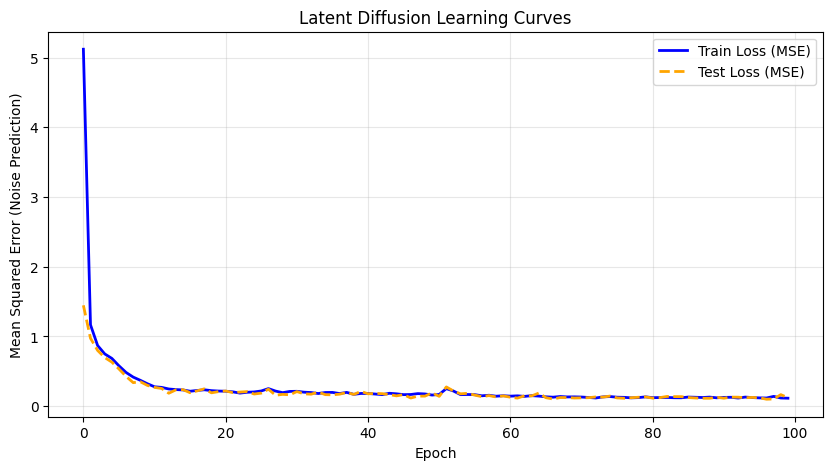

In [ ]:
# --- 1. Train / Test Split ---
# We have 1000 images. Let's use 900 for training and 100 for testing.
SPLIT_IDX = 900
X_train, X_test = X_data[:SPLIT_IDX], X_data[SPLIT_IDX:]
C_train, C_test = C_data[:SPLIT_IDX], C_data[SPLIT_IDX:]

# --- 2. Training Configuration ---
BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-3

# Optax requires combining models if we want to train them jointly
class JointModel(eqx.Module):
    text_enc: TextEncoder
    unet: ConditionalUNet

    def __call__(self, x_t, t, tokens):
        ctx = self.text_enc(tokens)
        return self.unet(x_t, t, ctx)

joint_model = JointModel(text_encoder, unet)
optimizer = optax.adam(LR)
opt_state = optimizer.init(eqx.filter(joint_model, eqx.is_array))

# --- 3. Loss & Step Functions ---
def loss_fn(model, x_0, tokens, t, noise):
    """Core MSE calculation between true noise and predicted noise."""
    x_t = q_sample(x_0, t, noise)
    # Batched forward pass
    predicted_noise = jax.vmap(model)(x_t, t, tokens)
    return jnp.mean(jnp.square(noise - predicted_noise))

@eqx.filter_jit
def train_step(model, opt_state, x_0, tokens, t, noise):
    """Calculates loss, computes gradients, and updates model weights."""
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x_0, tokens, t, noise)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

@eqx.filter_jit
def eval_step(model, x_0, tokens, t, noise):
    """Calculates loss without updating weights (for the test curve)."""
    return loss_fn(model, x_0, tokens, t, noise)

# --- 4. Training Loop ---
print("Training Joint Text-to-Image Diffusion Model...")
rng = jax.random.PRNGKey(111)

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    epoch_train_loss = 0.0
    n_batches = len(X_train) // BATCH_SIZE

    # Shuffle Training Data
    rng, shuffle_key = jax.random.split(rng)
    indices = jax.random.permutation(shuffle_key, len(X_train))

    # -- Training Phase --
    for i in range(n_batches):
        idx = indices[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        bx = X_train[idx]
        btok = C_train[idx]

        # Sample random timesteps and noise for this batch
        rng, t_key, n_key = jax.random.split(rng, 3)
        bt = jax.random.randint(t_key, (BATCH_SIZE,), 0, TIMESTEPS)
        bnoise = jax.random.normal(n_key, bx.shape)

        joint_model, opt_state, loss = train_step(joint_model, opt_state, bx, btok, bt, bnoise)
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    # -- Evaluation Phase --
    # Process the entire test set in one batch
    rng, t_test_key, n_test_key = jax.random.split(rng, 3)
    test_batch_size = len(X_test)
    test_t = jax.random.randint(t_test_key, (test_batch_size,), 0, TIMESTEPS)
    test_noise = jax.random.normal(n_test_key, X_test.shape)

    test_loss = eval_step(joint_model, X_test, C_test, test_t, test_noise).item()
    test_losses.append(test_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# --- 5. Render Learning Curves ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss (MSE)", color="blue", linewidth=2)
plt.plot(test_losses, label="Test Loss (MSE)", color="orange", linewidth=2, linestyle="--")
plt.title("Latent Diffusion Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Noise Prediction)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Rendering the Complete Joint Architecture

Our `JointModel` handles two entirely different modalities (Text and Images) and merges them to predict noise. To help visualize how the data flows through this complex system, we can render a blueprint of the architecture.

Notice specifically the **Bottleneck** in the center: this is where the mathematical "guidance" actually happens. The text context and the timestep are projected into the exact same dimension as the compressed image features and added together.

Rendering Architecture Blueprint...


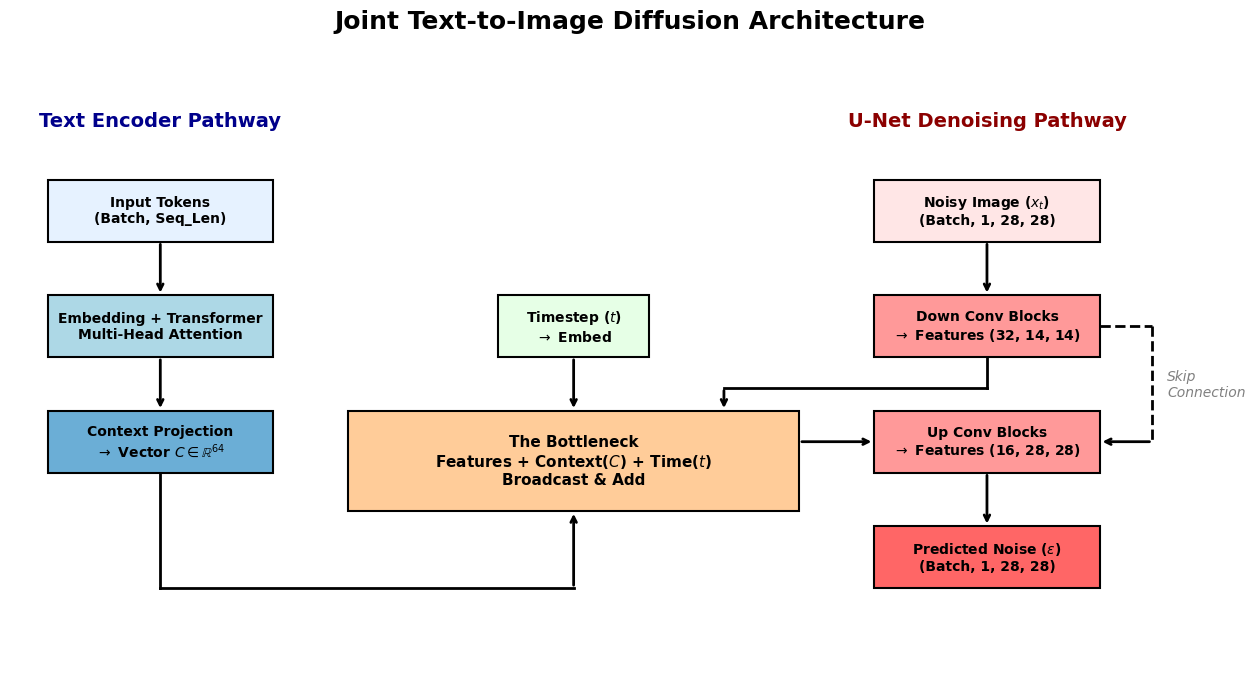

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def render_joint_model_blueprint_wide(model):
    # Increased width from 14 to 16 to accommodate the spread
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('off')

    # Helper to draw boxes
    def draw_box(x, y, w, h, text, color, text_size=10):
        ax.add_patch(patches.Rectangle((x, y), w, h, fc=color, ec="black", lw=1.5))
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', weight='bold', fontsize=text_size)

    # Helper to draw arrows
    def draw_arrow(x1, y1, x2, y2):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=2, color="black"))

    # ==========================================
    # 1. TEXT ENCODER (Left Side)
    # ==========================================
    ax.text(2, 7.5, "Text Encoder Pathway", ha='center', fontsize=14, weight='bold', color='darkblue')

    draw_box(0.5, 6, 3, 0.8, "Input Tokens\n(Batch, Seq_Len)", "#e6f2ff")
    draw_arrow(2, 6, 2, 5.3)

    draw_box(0.5, 4.5, 3, 0.8, "Embedding + Transformer\nMulti-Head Attention", "#add8e6")
    draw_arrow(2, 4.5, 2, 3.8)

    draw_box(0.5, 3, 3, 0.8, "Context Projection\n$\\rightarrow$ Vector $C \\in \\mathbb{R}^{64}$", "#6baed6")

    # Route Context to center of Bottleneck (x=7.5)
    ax.plot([2, 2], [3, 1.5], color="black", lw=2)
    ax.plot([2, 7.5], [1.5, 1.5], color="black", lw=2)
    draw_arrow(7.5, 1.5, 7.5, 2.5)

    # ==========================================
    # 2. THE BOTTLENECK & TIMESTEP (Center)
    # ==========================================
    # Timestep Input (Centered at x=7.5)
    draw_box(6.5, 4.5, 2, 0.8, "Timestep ($t$)\n$\\rightarrow$ Embed", "#e6ffe6")
    draw_arrow(7.5, 4.5, 7.5, 3.8)

    # Bottleneck Injection
    draw_box(4.5, 2.5, 6, 1.3, "The Bottleneck\nFeatures + Context($C$) + Time($t$)\nBroadcast & Add", "#ffcc99", text_size=11)

    # ==========================================
    # 3. U-NET DENOISER (Shifted Right)
    # ==========================================
    ax.text(13, 7.5, "U-Net Denoising Pathway", ha='center', fontsize=14, weight='bold', color='darkred')

    # Input Image
    draw_box(11.5, 6, 3, 0.8, "Noisy Image ($x_t$)\n(Batch, 1, 28, 28)", "#ffe6e6")
    draw_arrow(13, 6, 13, 5.3)

    # Down Block
    draw_box(11.5, 4.5, 3, 0.8, "Down Conv Blocks\n$\\rightarrow$ Features (32, 14, 14)", "#ff9999")

    # Route Down Conv into the Bottleneck
    ax.plot([13, 13], [4.5, 4.1], color="black", lw=2)
    ax.plot([13, 9.5], [4.1, 4.1], color="black", lw=2)
    draw_arrow(9.5, 4.1, 9.5, 3.8) # Arrows down into the right side of bottleneck roof

    # Up Block
    draw_box(11.5, 3, 3, 0.8, "Up Conv Blocks\n$\\rightarrow$ Features (16, 28, 28)", "#ff9999")

    # Route Bottleneck OUT to the Up Conv
    draw_arrow(10.5, 3.4, 11.5, 3.4) # Straight line from bottleneck right edge to Up block left edge

    # Skip Connection Path (Around the right side)
    ax.plot([14.5, 15.2], [4.9, 4.9], color="black", lw=2, linestyle="--")
    ax.plot([15.2, 15.2], [4.9, 3.4], color="black", lw=2, linestyle="--")
    draw_arrow(15.2, 3.4, 14.5, 3.4)
    ax.text(15.4, 4.15, "Skip\nConnection", ha='left', va='center', style='italic', color='gray')

    # Output Box
    draw_box(11.5, 1.5, 3, 0.8, "Predicted Noise ($\\epsilon$)\n(Batch, 1, 28, 28)", "#ff6666")
    draw_arrow(13, 3, 13, 2.3)

    plt.title("Joint Text-to-Image Diffusion Architecture", fontsize=18, weight='bold', y=1.02)

    # Expanded limits to account for the wider layout
    plt.xlim(0, 16.5)
    plt.ylim(0.5, 8.5)
    plt.show()

# Render the updated blueprint
print("Rendering Architecture Blueprint...")
render_joint_model_blueprint_wide(joint_model)

##Profiling the Model Scale (Parameter Counting)

How "big" is our model? In modern deep learning, the size of a model is measured by its Parameter Count (the total number of individual weights and biases the optimizer has to adjust).

State-of-the-art models like Stable Diffusion 1.5 have around 860 Million parameters in the U-Net alone.

Let's write a utility function to traverse our Equinox PyTree and build a table to see exactly how many parameters our "toy" Latent Diffusion Model has, broken down by its sub-components.

In [ ]:
def print_deep_parameter_table(model):
    # Helper to count parameters in any specific module or list of modules
    def count_params(module):
        # 1. Filter out functions/static configs, keeping only JAX arrays
        arrays = eqx.filter(module, eqx.is_array)
        # 2. Extract all the arrays into a flat list
        leaves = jax.tree_util.tree_leaves(arrays)
        # 3. Sum the total number of elements across all arrays
        return sum(x.size for x in leaves)

    # --- Calculate Counts ---
    total_params = count_params(model)

    # Text Encoder Sub-components
    text_total = count_params(model.text_enc)
    text_emb = count_params(model.text_enc.embedding)
    text_attn = count_params(model.text_enc.transformer)
    text_proj = count_params(model.text_enc.proj)

    # Deep U-Net Sub-components (Updated for Lists)
    unet_total = count_params(model.unet)
    unet_in = count_params(model.unet.conv_in)
    unet_down = count_params(model.unet.down_blocks) # Traverses the list!
    unet_t_proj = count_params(model.unet.time_proj)
    unet_c_proj = count_params(model.unet.context_proj)
    unet_up = count_params(model.unet.up_blocks)     # Traverses the list!
    unet_out = count_params(model.unet.conv_out)

    # --- Render the Table ---
    print("="*65)
    print(f"{'DEEP JOINT MODEL PARAMETER PROFILE':^65}")
    print("="*65)
    print(f"{'Component':<45} | {'Parameters':>15}")
    print("-" * 65)

    # Text Encoder Section
    print(f"{'1. Text Encoder (Total)':<45} | {text_total:>15,}")
    print(f"{'   ├─ Token Embedding':<45} | {text_emb:>15,}")
    print(f"{'   ├─ Multi-Head Attention':<45} | {text_attn:>15,}")
    print(f"{'   └─ Context Projection':<45} | {text_proj:>15,}")
    print("-" * 65)

    # U-Net Section
    num_layers = len(model.unet.down_blocks)
    print(f"{'2. Deep Denoising U-Net (Total)':<45} | {unet_total:>15,}")
    print(f"{'   ├─ Input Convolution':<45} | {unet_in:>15,}")
    print(f"{f'   ├─ Downsample Blocks (x{num_layers})':<45} | {unet_down:>15,}")
    print(f"{'   ├─ Timestep Projection':<45} | {unet_t_proj:>15,}")
    print(f"{'   ├─ Text Context Projection':<45} | {unet_c_proj:>15,}")
    print(f"{f'   ├─ Upsample Blocks (x{num_layers})':<45} | {unet_up:>15,}")
    print(f"{'   └─ Output Convolution':<45} | {unet_out:>15,}")
    print("="*65)

    # Grand Total
    print(f"{'GRAND TOTAL':<45} | {total_params:>15,} parameters")
    print("="*65)

# Assuming you instantiated 'joint_model' using the DeepConditionalUNet in Part 6!
print_deep_parameter_table(joint_model)

               DEEP JOINT MODEL PARAMETER PROFILE                
Component                                     |      Parameters
-----------------------------------------------------------------
1. Text Encoder (Total)                       |           6,912
   ├─ Token Embedding                         |             704
   ├─ Multi-Head Attention                    |           4,096
   └─ Context Projection                      |           2,112
-----------------------------------------------------------------
2. Deep Denoising U-Net (Total)               |         193,793
   ├─ Input Convolution                       |             320
   ├─ Downsample Blocks (x2)                  |          92,352
   ├─ Timestep Projection                     |             256
   ├─ Text Context Projection                 |           8,320
   ├─ Upsample Blocks (x2)                    |          92,256
   └─ Output Convolution                      |             289
GRAND TOTAL                       

#Part 7: Inference - Generating a New Image from Text

To generate an image, we perform the Reverse Diffusion Process.

1. We start with a canvas of pure Gaussian noise ($x_T$).

2. We encode the user's prompt into an embedding.

3. We loop backward from $t = T$ down to $0$. At each step, the U-Net predicts the noise in the image based on the prompt.

4. We mathematically subtract a fraction of that predicted noise to arrive at $x_{t-1}$.

Generating image for prompt: 'A black and white image of a sneaker'


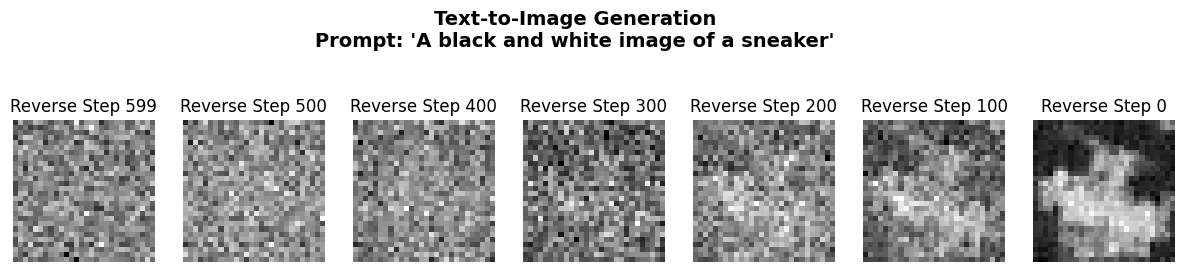

Generation took 265.40 seconds.


In [ ]:
import time


@eqx.filter_jit
def reverse_step(model, x_t, tokens, t, t_index):
    """A simplified DDPM reverse step for timestep t -> t-1"""
    # Predict noise (passing `t` directly as a scalar)
    pred_noise = model(x_t, t, tokens)

    # Retrieve schedules
    b_t = beta[t]
    a_t = alpha[t]
    a_bar_t = alpha_bar[t]

    # Compute the mean of the posterior, applying Langevin Dynamics
    mean = (1 / jnp.sqrt(a_t)) * (x_t - (b_t / jnp.sqrt(1 - a_bar_t)) * pred_noise)

    # Add Langevin noise (unless we are at the final step t=0)
    def add_noise():
        rng = jax.random.PRNGKey(t_index)
        z = jax.random.normal(rng, x_t.shape)
        variance = jnp.sqrt(b_t) * z
        return mean + variance

    return jax.lax.cond(t > 0, add_noise, lambda: mean)


def generate_image_from_text(model, prompt):
    print(f"Generating image for prompt: '{prompt}'")

    # Encode prompt
    tokens = tokenize(prompt)

    # 1. Start with pure noise
    rng = jax.random.PRNGKey(999)
    x = jax.random.normal(rng, (1, 28, 28))

    history = []

    # 2. Reverse Diffusion Loop
    step_size = int(TIMESTEPS / 6)
    for t_idx in reversed(range(TIMESTEPS)):
        x = reverse_step(model, x, tokens, t_idx, t_idx)
        if t_idx % step_size == 0 or t_idx == TIMESTEPS - 1:
            history.append((t_idx, np.array(x)))

    # 3. Render Generation Stages
    fig, axes = plt.subplots(1, len(history), figsize=(15, 3))
    for i, (t, img) in enumerate(history):
        axes[i].imshow(img[0], cmap='gray')
        axes[i].set_title(f"Reverse Step {t}")
        axes[i].axis('off')

    plt.suptitle(f"Text-to-Image Generation\nPrompt: '{prompt}'", y=1.1, fontsize=14, weight='bold')
    plt.show()

# --- Test the Model! ---
# Our model was trained on simple Fashion-MNIST captions
test_prompt = "A black and white image of a sneaker"
t0 = time.time()
generate_image_from_text(joint_model, test_prompt)
t1 = time.time()
print(f"Generation took {t1 - t0:.2f} seconds.")

##Fast Sampling with DDIM (Skipping Steps)

Our current generation loop uses **DDPM** (Denoising Diffusion Probabilistic Models). It is a "Markov Chain," meaning to get to step 999, it must pass through step 1000. Going from pure noise to a clean image requires 1,000 sequential passes through the U-Net, which is incredibly slow.

However, because our U-Net has learned the continuous **Score Function** (the exact mathematical direction of the clean image), we can rethink the reverse process.

Instead of adding random noise at every step, **DDIM** makes the reverse process entirely deterministic. It uses the U-Net's noise prediction to guess what the final clean image ($x_0$) looks like immediately, and then points a straight line toward the next timestep ($x_{t-\Delta t}$).

Because it's a straight line, we can take massive leaps—skipping 20, 50, or even 100 steps at a time!

Here is the DDIM math we will implement:

1. **Predict the final clean image** ($x_0$):

$$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon_\theta(x_t)}{\sqrt{\bar{\alpha}_t}}$$

2. **Point toward the next skipped timestep** ($x_{t-\Delta t}$):

$$x_{t-\Delta t} = \sqrt{\bar{\alpha}_{t-\Delta t}} \cdot \hat{x}_0 + \sqrt{1 - \bar{\alpha}_{t-\Delta t}} \cdot \epsilon_\theta(x_t)$$

Running Fast DDIM Sampling (50 steps instead of 600)...


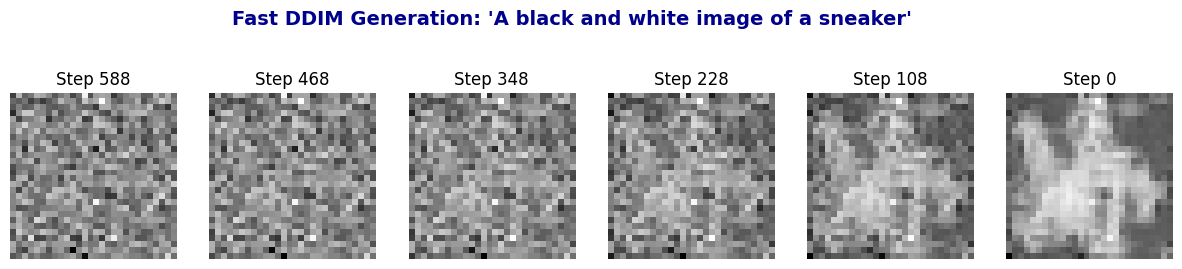

Generation took 16.97 seconds.


In [ ]:

# --- 2. The DDIM Reverse Step ---
@eqx.filter_jit
def ddim_step(model, x_t, tokens, t, t_next):
    """Takes a massive leap from t to t_next (skipping intermediate steps)"""
    # Notice: No vmap needed! We are processing exactly 1 image.
    pred_noise = model(x_t, t, tokens)

    a_t = alpha_bar[t]
    a_next = jax.lax.cond(t_next >= 0, lambda: alpha_bar[t_next], lambda: 1.0)

    pred_x0 = (x_t - jnp.sqrt(1 - a_t) * pred_noise) / jnp.sqrt(a_t)
    dir_xt = jnp.sqrt(1 - a_next) * pred_noise

    x_next = jnp.sqrt(a_next) * pred_x0 + dir_xt
    return x_next

# --- 3. Fast Sampling Loop ---
def generate_fast_ddim(model, prompt_string, num_steps=50):
    print(f"Running Fast DDIM Sampling ({num_steps} steps instead of {TIMESTEPS})...")

    LOCAL_SEQ_LENGTH = 8

    # 1. UNBATCHED Tokens: Shape (8,)
    # tokens = tokenize_prompt(prompt_string, vocab, LOCAL_SEQ_LENGTH)
    tokens = tokenize(prompt_string)

    rng = jax.random.PRNGKey(999)
    # 2. UNBATCHED Image: Shape (Channels, Height, Width) -> (1, 28, 28)
    x = jax.random.normal(rng, (1, 28, 28))

    step_size = TIMESTEPS // num_steps
    time_sequence = list(reversed(range(0, TIMESTEPS, step_size)))

    history = []

    for i in range(len(time_sequence)):
        t = time_sequence[i]
        t_next = time_sequence[i+1] if i < len(time_sequence) - 1 else -1

        # 3. Pass simple integer scalars for t and t_next
        x = ddim_step(model, x, tokens, t, t_next)

        if i % max(1, (num_steps // 5)) == 0 or i == len(time_sequence) - 1:
            history.append((t, np.array(x)))

    # --- Render Results ---
    fig, axes = plt.subplots(1, len(history), figsize=(15, 3))
    for i, (t_val, img) in enumerate(history):
        # img is now (1, 28, 28), so img[0] gets the 28x28 spatial grid
        display_img = (img[0] + 1.0) / 2.0
        axes[i].imshow(display_img, cmap='gray')
        axes[i].set_title(f"Step {t_val}")
        axes[i].axis('off')

    plt.suptitle(f"Fast DDIM Generation: '{prompt_string}'", y=1.05, fontsize=14, color='darkblue', weight='bold')
    plt.show()

# Let's test it! Generating an image in 50 steps.
t0 = time.time()
generate_fast_ddim(joint_model, 'A black and white image of a sneaker', num_steps=50)
t1 = time.time()
print(f"Generation took {t1 - t0:.2f} seconds.")

#Part 8: Scaling to State-of-the-Art (Why does our model look blurry?)

If you look at the generated images, they likely resemble vague blobs rather than crisp clothing. This is by design! We trained a tiny network on 1,000 images for a few minutes.To turn this architecture into a photorealistic powerhouse like Stable Diffusion, researchers rely on five massive upgrades:

##1. Pre-trained Vision-Language Encoders (CLIP)
In our toy model, we trained a tiny text encoder from scratch alongside the U-Net. SOTA models do not do this. They use massive, pre-trained text encoders like [OpenAI's CLIP](https://openai.com/index/clip/) or [Google's T5-XXL](https://en.wikipedia.org/wiki/T5_(language_model). These models have already read the entire internet and possess a deeply nuanced, high-dimensional understanding of how words map to visual concepts. By "freezing" a pre-trained CLIP model and using it to encode the prompt, the U-Net gets a massive head start.

##2. Cross-Attention Mechanisms
Look at how we injected the text into our U-Net:


`h2 = h2 + cond  # Simple Addition!`


Adding the text embedding directly to the pixel features is a severe bottleneck. SOTA models use **Cross-Attention**.

In a Cross-Attention block, the image features act as the Queries, and the Text Embeddings act as the Keys and Values. This allows every specific "patch" of the image to look at the entire sentence and decide which words are most relevant to it (e.g., the top-left pixels attend to the word "sky", while the bottom pixels attend to "grass").

##3. A Highly Expressive, Pre-Trained VAE
To save time in this tutorial, we skipped using our VAE and diffused raw pixels. Real **Latent Diffusion Models (LDMs)** use a VAE that was pre-trained for weeks on millions of high-resolution images.

Here is exactly how the VAE transforms the pipeline:

* **During Training (The Encoder)**: Instead of feeding a massive $512 \times 512 \times 3$ pixel image to the U-Net, we first pass it through the frozen VAE Encoder. The Encoder compresses it into a tiny $64 \times 64 \times 4$ **Latent Grid**. We add noise to this tiny grid, and train the U-Net to denoise it.

* **During Inference (The Decoder)**: When a user types a prompt, the U-Net starts with a $64 \times 64 \times 4$ grid of pure noise and denoises it. The U-Net's final output is still just a tiny latent vector. Finally, we pass that clean vector through the frozen VAE Decoder, which translates it back into a stunning $512 \times 512 \times 3$ pixel image.

**The Overall Improvement**: By moving the diffusion process into the compressed Latent Space, we shrink the computational workload by a factor of 64! This makes the U-Net incredibly fast to train and run. Furthermore, because the pre-trained VAE Decoder already knows how to perfectly reconstruct microscopic details (like sharp edges, lighting, and textures), the U-Net doesn't have to waste time learning how to draw high-frequency details. It only has to learn the high-level semantic layout (e.g., "*put a shoe here*"), resulting in a massive leap in photorealism.

##4. The Bitter Lesson (Scale & Data)
Our model saw 1,000 grayscale, $28 \times 28$ images. Stable Diffusion was trained on LAION-5B, a dataset of 5.8 billion high-resolution image-text pairs, using hundreds of A100 GPUs for hundreds of thousands of hours. Neural networks scale remarkably well; giving our exact architecture 1,000x more data and parameters would drastically improve it.

##5. The "Magic Trick": Classifier-Free Guidance (CFG)

Perhaps the most impactful architectural trick used at inference time is **Classifier-Free Guidance (CFG)**.

When a model is unsure about a prompt, it tends to generate a "safe," blurry average of many possible images. CFG forces the model to amplify the features that are specific to the text prompt.

During training, we randomly drop the text prompt 10% of the time (replacing it with an empty string). This teaches the U-Net how to do unconditional generation $\epsilon_{uncond}$ (just generating random stuff) alongside conditional generation $\epsilon_{cond}$ (following the prompt).

During the reverse diffusion loop (inference), we run the U-Net twice at every timestep: once with the prompt, and once without it. We then extrapolate the difference between them using a guidance scale $w$ (usually between 7 and 10):

$$\hat{\epsilon} = \epsilon_{uncond} + w \cdot (\epsilon_{cond} - \epsilon_{uncond})$$


By pointing the vector away from the generic, unprompted prediction and pushing it heavily towards the prompted prediction, the resulting image becomes exponentially crisper and more aligned with the text.